In [1]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import g0
from scipy.optimize import curve_fit, minimize

In [2]:
# 讀取資料
fname = './data_8.csv'
data = pd.read_csv(fname).dropna() # dropna() 殺掉空格
print(data.columns)

Index(['Length (m)', 'Duration of 10 swings (s)', 'Duration of a swing (s)',
       'Average Period of a Swing (s)', 'SD of T (s)',
       'Theoretical Value of Oscillation Period (s)', 'Error Calculation (%)'],
      dtype='str')


In [3]:
# 製作空白列表（以後當作資料儲存容器）
length_list = []
avg_period_list = []
std_list = [] # 標準差
all_periods = []
all_lengths = []

# 依擺長自動分組
length_groups = data.groupby('Length (m)')
for L, group in length_groups:
    
    periods = group['Duration of a swing (s)'].values
    
    avg_T = np.mean(periods)
    std_T = np.std(periods, ddof=1)  # 用樣本標準差
    
    length_list.append(L)
    avg_period_list.append(avg_T)
    std_list.append(std_T)
    
    all_lengths.extend([L]*len(periods))
    all_periods.extend(periods)

/Users/li-ling/Desktop/實驗物理學2/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/li-ling/Desktop/實驗物理學2/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
# 轉為 numpy array
length_array = np.array(length_list)
avg_period_array = np.array(avg_period_list)
std_array = np.array(std_list)

all_periods = np.array(all_periods)
all_lengths = np.array(all_lengths)

In [5]:
# 理論曲線
l_axis = np.linspace(min(length_array)*0.9, max(length_array)*1.1, 200)
t_ideal = 2 * np.pi * np.sqrt(l_axis / g0.value)

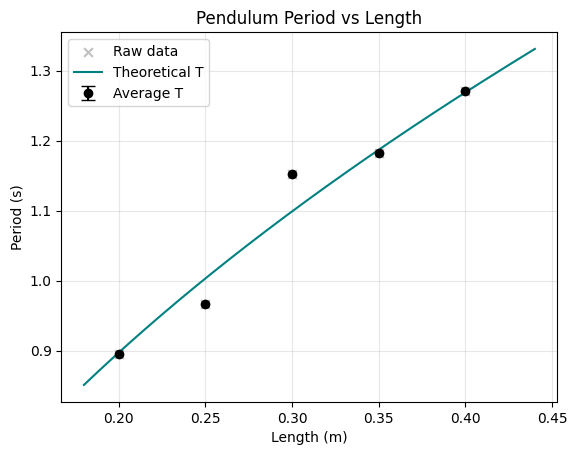

In [6]:
# 作圖
plt.scatter(all_lengths, all_periods, 
            s=40, marker='x', color='silver',
            label='Raw data')

plt.errorbar(length_array, avg_period_array,
             yerr=std_array,
             fmt='o', color='black',
             capsize=5, label='Average T')

plt.plot(l_axis, t_ideal,
         color='teal',
         label='Theoretical T')

plt.xlabel('Length (m)')
plt.ylabel('Period (s)')
plt.title('Pendulum Period vs Length')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
# 取 ln
lnL = np.log(length_array)
lnT = np.log(avg_period_array)

# 誤差傳播：σ(lnT) = σT / T
sigma_lnT = std_array / avg_period_array

# 檢查一下數值
print("lnL =", lnL)
print("lnT =", lnT)
print("sigma_lnT =", sigma_lnT)

lnL = [-1.60943791 -1.38629436 -1.2039728  -1.04982212 -0.91629073]
lnT = [-0.11093156 -0.03355678  0.14236724  0.16805358  0.23980399]
sigma_lnT = [nan nan nan nan nan]


一檢查就很明顯ㄌ，問題出在sigma_lnT = [nan nan nan nan nan]（根本沒有數值）
（等修正版再好好糾錯）

In [8]:
def linear_function(x, a, b):
    return a * x + b

x_plot = np.linspace(min(lnL)*0.95, max(lnL)*1.05, 100)

In [ ]:
# curve fitting
popt_cf, pcov_cf = curve_fit( # scipy中的函數，用來進行非線性最小平方擬合
    linear_function,
    lnL, # x-axis
    lnT, # y-axis
    sigma=sigma_lnT, # errorbar
    absolute_sigma=True # 確認將 sigma 視為絕對不確定
)
# 輸出結果
a_cf, b_cf = popt_cf # 將最佳擬合參數將最佳擬合參數a和b分別儲存到變數 a_cf 和 b_cf 中
a_err, b_err = np.sqrt(np.diag(pcov_cf)) # 擬合參數的共變異數矩陣，用於估計參數的不確定性

/var/folders/jv/t671b1nn6y15dk5xdwyl2pz80000gn/T/ipykernel_13879/81259893.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit( # scipy中的函數，用來進行曲線擬合


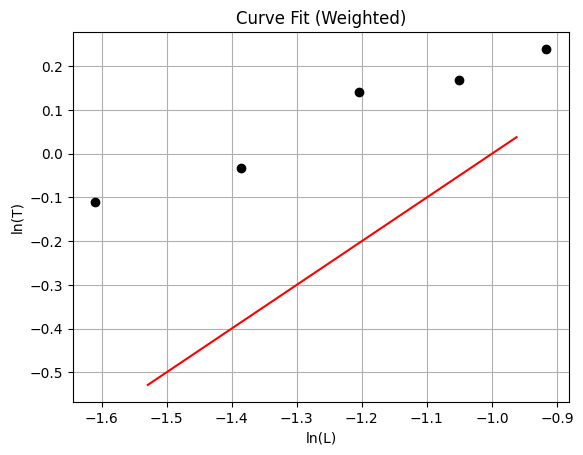

In [24]:
# 畫畫畫畫畫圖
plt.figure()
plt.errorbar(lnL, lnT, yerr=sigma_lnT, fmt='o', capsize=4, color='black', label='Average T') 
plt.plot(x_plot, linear_function(x_plot, a_cf, b_cf), color='red', label='curve_fit')
plt.title('Curve Fit (Weighted)')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid()
plt.show()

# yerr=sigma_lnT: y 軸誤差棒的長度，對應於每個資料點的標準差
# fmt='o': 資料點的樣式為圓點
# capsize=4: 誤差棒末端的橫線長度
# linear_function(x_plot, a_cf, b_cf):使用最佳擬合參數a和b計算y值

In [ ]:
print("==== Curve Fit Results ====")
print(f"Curve Fit: a={a_cf:.4f}, b={b_cf:.4f}")
g_cf  = np.exp(2*(np.log(2*np.pi) - b_cf))
print("\nDerived g values:")
print(f"Curve Fit: {g_cf:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Curve Fit Results ====
Curve Fit: a=1.0000, b=1.0000

Derived g values:
Curve Fit: 5.3428
Theoretical g  : 9.8066


很明顯擬合線偏離數據點，且a、b數值很怪，g誤差更是超大

In [ ]:
# Least Squares fitting
A = np.vstack([lnL, np.ones(len(lnL))]).T
a_ls, b_ls = np.linalg.lstsq(A, lnT, rcond=None)[0]

# lnL 是一個陣列或列表，代表自變數的資料
# np.ones(len(lnL))：
# 建立一個與 lnL 長度相同的陣列，內容全為 1，這是為了代表線性迴歸中的截距項（bias）。
# np.vstack([lnL, np.ones(len(lnL))])：將 lnL 和全為 1 的陣列垂直堆疊成一個 2xN 的矩陣，其中 N 是 lnL 的長度。
# .T：將矩陣轉置，變成 Nx2 的矩陣 A，每一列包含 [lnL[i], 1]

'''
np.linalg.lstsq(A, lnT, rcond=None)：
使用最小平方法（Least Squares Method）來解線性方程式 
A⋅[a,b]=lnT，其中：
A 是上述建立的 Nx2 矩陣
lnT 是目標變數（因變數）的資料
這個函式會回傳一個包含多個結果的陣列，其中 [0] 是第一個結果，代表解出的係數 [a_ls, b_ls]。
a_ls, b_ls ：
將回傳的係數解開，分別存到變數 a_ls 和 b_ls 中。
a_ls 是斜率（slope），b_ls 是截距（intercept）。
'''

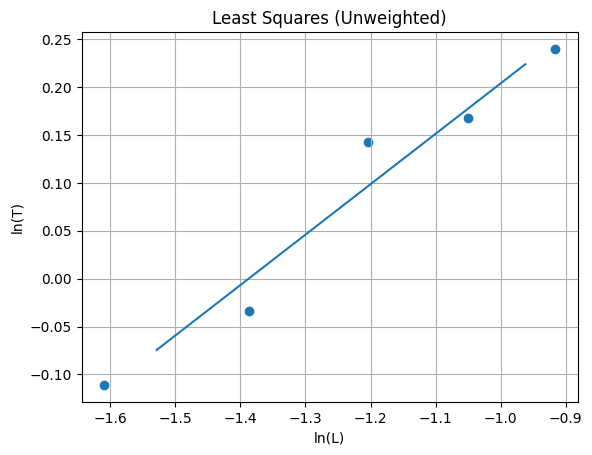

In [12]:
# 畫畫畫畫畫圖
plt.figure()
plt.scatter(lnL, lnT)
plt.plot(x_plot, linear_function(x_plot, a_ls, b_ls))
plt.title('Least Squares (Unweighted)')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid()
plt.show()

In [ ]:
print("==== Least Squares Fit Results ====")
print(f"Least Squares  : a={a_ls:.4f}, b={b_ls:.4f}")
g_ls  = np.exp(2*(np.log(2*np.pi) - b_ls))
print("\nDerived g values:")
print(f"Least Squares  : {g_ls:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Least Squares Fit Results ====
Least Squares  : a=0.5263, b=0.7301

Derived g values:
Least Squares  : 9.1659
Theoretical g  : 9.8066


In [ ]:
# Chi-square fitting
def chi_square(params): # params 是一個包含兩個參數的陣列 [a, b]，代表線性模型的斜率和截距
    a, b = params
    model = linear_function(lnL, a, b)
    return np.sum((lnT - model) ** 2 / sigma_lnT ** 2) # 卡方值

# 最小化卡方值
result = minimize(chi_square, x0=[0.5, 0.0]) # x0為初始猜測值
a_chi, b_chi = result.x

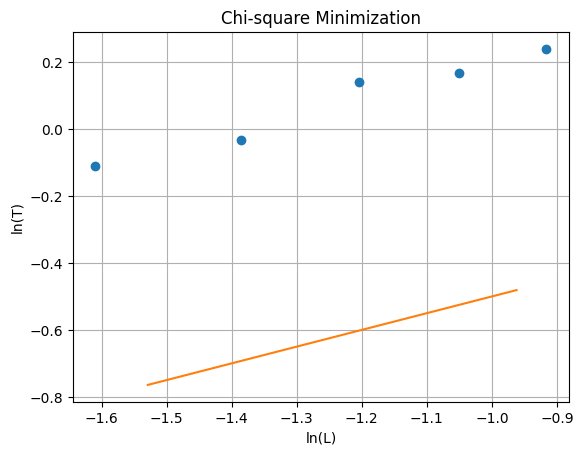

In [14]:
# 畫畫畫畫畫圖
plt.figure()
plt.errorbar(lnL, lnT, yerr=sigma_lnT, fmt='o', capsize=4)
plt.plot(x_plot, linear_function(x_plot, a_chi, b_chi))
plt.title('Chi-square Minimization')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid()
plt.show()

In [30]:
print("==== Chi-square Fit Results ====")
print(f"Chi-square Fit : a={a_chi:.4f}, b={b_chi:.4f}")
g_ls  = np.exp(2*(np.log(2*np.pi) - b_ls))
print("\nDerived g values:")
print(f"Chi-square Fit : {g_chi:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Chi-square Fit Results ====
Chi-square Fit : a=0.5000, b=0.0000

Derived g values:
Chi-square Fit : 39.4784
Theoretical g  : 9.8066


這邊感覺問題出在初始猜測值，因為把b=0.0000帶入linear_function，會得出g＝(２＊pi)^2=39.4784

In [ ]:
# 顯示數值比較
print("==== Fit Results ====")
print(f"Curve Fit      : a={a_cf:.4f}, b={b_cf:.4f}")
print(f"Least Squares  : a={a_ls:.4f}, b={b_ls:.4f}")
print(f"Chi-square Fit : a={a_chi:.4f}, b={b_chi:.4f}") # 格式化為小數點後四位數

==== Fit Results ====
Curve Fit      : a=1.0000, b=1.0000
Least Squares  : a=0.5263, b=0.7301
Chi-square Fit : a=0.5000, b=0.0000


In [16]:
# 由 b 反推 g
g_cf  = np.exp(2*(np.log(2*np.pi) - b_cf))
g_ls  = np.exp(2*(np.log(2*np.pi) - b_ls))
g_chi = np.exp(2*(np.log(2*np.pi) - b_chi))

print("\nDerived g values:")
print(f"Curve Fit      : {g_cf:.4f}")
print(f"Least Squares  : {g_ls:.4f}")
print(f"Chi-square Fit : {g_chi:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")


Derived g values:
Curve Fit      : 5.3428
Least Squares  : 9.1659
Chi-square Fit : 39.4784
Theoretical g  : 9.8066


從最後數據比較可以看出，牽涉到sigma值的擬合都出現明顯誤差，反而是不包含權重的最小平方法最符合理論預期，問題再次指向sigma